In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df_main = pd.read_pickle('data_files/df_main.pkl')

In [5]:
# Creating a df with only relevant features for modelling
df_ml = df_main.drop(['Season', 'Player', 'Tm', 'First', 'Rank', 'Pts Won', 'Pts Max'], axis=1)

In [6]:
df_ml

,Age,Share,G,MP,PTS,TRB,AST,STL,BLK,FG%,3P%,FT%,W,L,W/L%,PS/G,PA/G,Conference Ranking,Attempts_3P
0,27,0.991,82,39.4,24.2,13.9,5.0,1.5,2.2,0.499,0.256,0.791,58.0,24.0,0.707,94.5,89.1,1.0,1
1,27,0.582,69,36.6,22.3,12.4,3.1,0.9,2.7,0.501,0.167,0.599,57.0,25.0,0.695,91.5,84.3,2.0,1
2,25,0.425,78,35.7,20.1,10.0,2.1,0.8,2.6,0.434,0.111,0.757,61.0,21.0,0.744,91.4,85.6,1.0,1
3,26,0.228,81,40.3,24.2,6.3,2.1,1.3,0.2,0.480,0.433,0.927,55.0,27.0,0.671,102.8,97.8,4.0,1
4,25,0.172,65,37.6,24.0,5.5,5.1,1.7,0.4,0.438,0.327,0.852,56.0,26.0,0.683,98.2,94.3,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,27,0.143,77,35.4,28.7,3.6,6.7,0.9,0.2,0.479,0.401,0.847,50.0,32.0,0.610,112.8,108.2,2.0,1
280,25,0.087,74,35.7,26.9,8.1,4.9,1.0,0.6,0.471,0.376,0.833,64.0,18.0,0.780,120.6,109.2,1.0,1
281,22,0.018,79,35.1,25.9,5.4,5.1,1.3,0.5,0.461,0.357,0.836,56.0,26.0,0.683,113.0,106.5,3.0,1
282,27,0.003,82,35.7,19.4,13.7,8.2,0.9,0.6,0.594,0.379,0.704,46.0,36.0,0.561,116.6,114.8,9.0,1


In [63]:
# train-test split
from sklearn.model_selection import train_test_split

X = df_ml.drop('Share', axis=1)
y = df_ml['Share']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Model training
import xgboost
from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [23]:
# predictions
y_pred = model.predict(X_test)

In [24]:
# evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


MSE: 0.0488
RMSE: 0.2210
MAE: 0.1362
R² Score: 0.4268


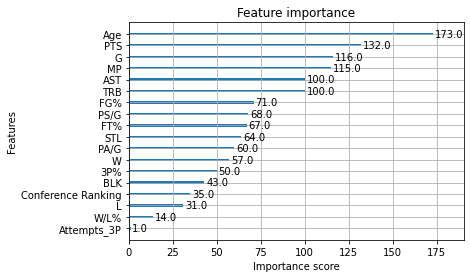

In [25]:
# feature importance

xgboost.plot_importance(model)
plt.show()

In [39]:
# fine tune using RandomizedSearchCV and adjusssting parameters below to obtain a better score

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from scipy.stats import uniform, randint

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(2, 12),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 0.3),
    'reg_lambda': uniform(0, 2)
}

model = XGBRegressor()
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=200,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_


In [40]:
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² Score: {r2:.4f}')

MSE: 0.0408
RMSE: 0.2021
MAE: 0.1417
R² Score: 0.5206


After finetuning, I have obtained a better score. Now I am going to try out linear regression, random forest regressor and gradient boosting regressor.

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}:\nMSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}\n")


In [43]:
# linear regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluate_model(y_test, y_pred_lr, lr)

LinearRegression():
MSE: 0.0357, RMSE: 0.1888, MAE: 0.1522, R²: 0.5814



In [45]:
# Random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_model(y_test, y_pred_rf, rf)

RandomForestRegressor(random_state=42):
MSE: 0.0557, RMSE: 0.2360, MAE: 0.1544, R²: 0.3461



In [ ]:
# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)
evaluate_model(y_test, y_pred_gbr, gbr)

GradientBoostingRegressor(random_state=42):
MSE: 0.0449, RMSE: 0.2119, MAE: 0.1399, R²: 0.4731



Since Linear regression has a better MAE and R^2 score than XGBoost and gradientboost's scores are not that far off. However, random forest has a rather poor r^2 score so I will not be using it.

In [48]:
# Fine tune GradientBoost

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0],
    'max_features': ['auto', 'sqrt', 'log2']
}


gbr = GradientBoostingRegressor(random_state=42)
random_search = RandomizedSearchCV(
    gbr,
    param_distributions=param_dist,
    n_iter=100,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_gbr = random_search.best_estimator_

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\tree\_classes.py:306: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1

In [50]:
y_pred = best_gbr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² Score: {r2:.4f}')

MSE: 0.0447
RMSE: 0.2115
MAE: 0.1329
R² Score: 0.4748


Gradient Boosting's scores has improved after finetune but still not beating xgboost. I am revisiting linear regression, seeing the performance after fixes to skewness and feature collinearity.

In [ ]:
# see skewness

features = ['Age', 'PTS', 'AST', 'TRB', 'STL','BLK', 'FG%', '3P%','FT%', 'W/L%', 'PS/G', 'PA/G', 'Conference Ranking']
df_main[features].skew().sort_values(ascending=False)

BLK                   1.237844
Conference Ranking    0.994141
FG%                   0.892970
STL                   0.461452
TRB                   0.440648
Age                   0.428972
AST                   0.406992
PA/G                  0.187432
PS/G                  0.075939
PTS                  -0.319357
W/L%                 -0.452916
3P%                  -0.863747
FT%                  -1.242117
dtype: float64

In [53]:
# Since |skewness| is rather high for BLK, Conference ranking, FG% (right skewed), 3P% and FT%(left skewed), we transform these features.
df_main['BLK'] = np.log1p(df_main['BLK'])
df_main['Conference Ranking'] = np.log1p(df_main['Conference Ranking'])
df_main['FG%'] = np.log1p(df_main['FG%'])
df_main['FT%'] = np.log1p(1 - df_main['FT%'])
df_main['3P%'] = np.log1p(1 - df_main['3P%'])
# Left-skewed fix (invert % before log)

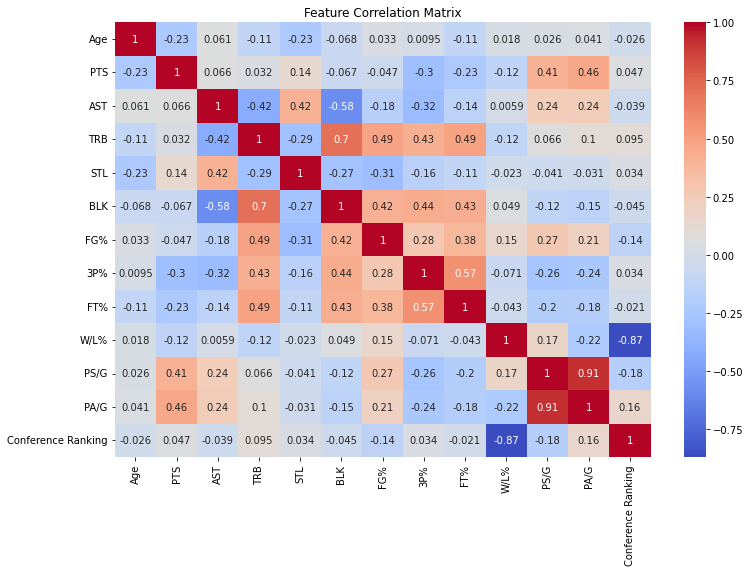

In [55]:
plt.figure(figsize=(12,8))
sns.heatmap(df_main[features].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [56]:
# drop those features who have > |0.8| in collinearity
df_main = df_main.drop(['PS/G', 'Conference Ranking'], axis=1)

In [60]:
# drop addtional columns
df_main = df_main.drop(['Season', 'Player', 'Tm', 'First', 'Rank', 'Pts Won', 'Pts Max'], axis=1)

In [61]:
# Retry linear regression
from sklearn.model_selection import train_test_split

X = df_main.drop('Share', axis=1)
y = df_main['Share']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


MSE: 0.0393
RMSE: 0.1983
MAE: 0.1685
R² Score: 0.5377


As compared to xgboost, MSE: 0.0408, RMSE: 0.2021, MAE: 0.1417 and R² Score: 0.5206, the scoring for linear regression is better but worst then the original linear regression model earlier, I will focus on finetuning the original linear regression model using ridge and lasso.

In [64]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Ridge Regression with cross-validation
ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Lasso Regression with cross-validation
lasso = LassoCV(alphas=np.logspace(-3, 3, 100), cv=5, max_iter=5000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# Evaluate both
def evaluate(name, y_true, y_pred):
    print(f"\n{name} Results")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R² Score:", r2_score(y_true, y_pred))

evaluate("Ridge", y_test, y_pred_ridge)
evaluate("Lasso", y_test, y_pred_lasso)



Ridge Results
MSE: 0.03682434833461671
RMSE: 0.19189671267277278
MAE: 0.1517205068024213
R² Score: 0.5677799029400206

Lasso Results
MSE: 0.03931864139359991
RMSE: 0.19828928713775718
MAE: 0.16184193473136513
R² Score: 0.5385035236745033



Original linear regression (MSE: 0.0357, RMSE: 0.1888, MAE: 0.1522, R²: 0.5814) still perform better than ridge and lasso regression.

Since I have been using models like Linear Regression, XGBoost, and Ridge, we can combine them into an ensemble using the Voting Regressor.

In [74]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge

# Define individual models
model1 = LinearRegression()
model2 = XGBRegressor()
model3 = Ridge()

# Create a voting regressor with the models
voting_regressor = VotingRegressor(estimators=[('lr', model1), ('xgb', model2), ('ridge', model3)])

# Train the ensemble model
voting_regressor.fit(X_train, y_train)

# Make predictions
y_pred = voting_regressor.predict(X_test)

# Evaluate the model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R² Score: {r2}")


MSE: 0.03283112590327519
RMSE: 0.18119361441087042
MAE: 0.1363838854680298
R² Score: 0.6146497340412551


Scores got better after combining the 3 models. 